In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb

In [12]:
df = pd.read_csv('/KAG_conversion_data.csv')
print(df.head())
print(df.info())
print(df.isnull().sum())
print(df.duplicated().sum())
print(df.describe())
print(df['xyz_campaign_id'].value_counts())


    ad_id  xyz_campaign_id  fb_campaign_id    age gender  interest  \
0  708746              916          103916  30-34      M        15   
1  708749              916          103917  30-34      M        16   
2  708771              916          103920  30-34      M        20   
3  708815              916          103928  30-34      M        28   
4  708818              916          103928  30-34      M        28   

   Impressions  Clicks  Spent  Total_Conversion  Approved_Conversion  
0         7350       1   1.43                 2                    1  
1        17861       2   1.82                 2                    0  
2          693       0   0.00                 1                    0  
3         4259       1   1.25                 1                    0  
4         4133       1   1.29                 1                    1  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1143 entries, 0 to 1142
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtyp

In [15]:
result = df.groupby('xyz_campaign_id')[['Spent', 'Approved_Conversion']].sum()
result['CPA'] = result['Spent'] / result['Approved_Conversion']
print(result)

                        Spent  Approved_Conversion        CPA
xyz_campaign_id                                              
916                149.710001                   24   6.237917
936               2893.369999                  183  15.810765
1178             55662.149959                  872  63.832741


In [16]:
age_result = df.groupby('age')[['Spent', 'Approved_Conversion']].sum()
age_result['CPA'] = age_result['Spent'] / age_result['Approved_Conversion']
print(age_result)

              Spent  Approved_Conversion        CPA
age                                                
30-34  15252.399986                  494  30.875304
35-39  11112.429994                  207  53.683237
40-44  11589.729981                  170  68.174882
45-49  20750.669997                  208  99.762837


In [19]:
age_result = df.groupby('gender')[['Spent', 'Approved_Conversion']].sum()
age_result['CPA'] = age_result['Spent'] / age_result['Approved_Conversion']
print(age_result)

               Spent  Approved_Conversion        CPA
gender                                              
F       34502.619963                  495  69.702263
M       24202.609995                  584  41.442825


In [20]:
cross = df.groupby(['xyz_campaign_id', 'age'])[['Spent', 'Approved_Conversion']].sum()
cross['CPA'] = cross['Spent'] / cross['Approved_Conversion']
print(cross)

                              Spent  Approved_Conversion         CPA
xyz_campaign_id age                                                 
916             30-34     75.330000                   11    6.848182
                35-39     23.640000                    6    3.940000
                40-44     16.810000                    4    4.202500
                45-49     33.930000                    3   11.310000
936             30-34    391.440000                   88    4.448182
                35-39    383.430001                   34   11.277353
                40-44    450.400000                   25   18.016000
                45-49   1668.099997                   36   46.336111
1178            30-34  14785.629986                  395   37.431975
                35-39  10705.359993                  167   64.103952
                40-44  11122.519981                  141   78.883120
                45-49  19048.639999                  169  112.713846


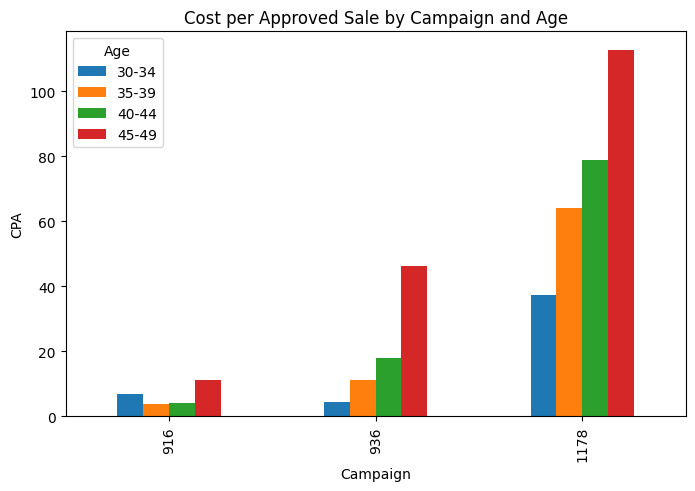

In [22]:
import matplotlib.pyplot as plt

cpa = cross['CPA'].unstack()
cpa.plot(kind='bar', figsize=(8, 5))
plt.title('Cost per Approved Sale by Campaign and Age')
plt.xlabel('Campaign')
plt.ylabel('CPA')
plt.legend(title='Age')
plt.show()


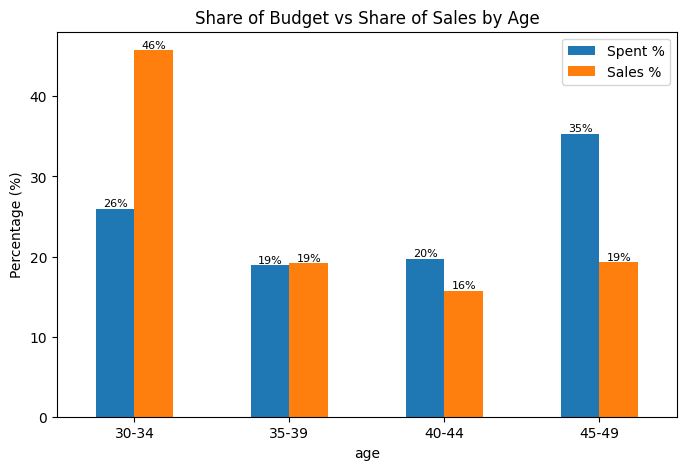

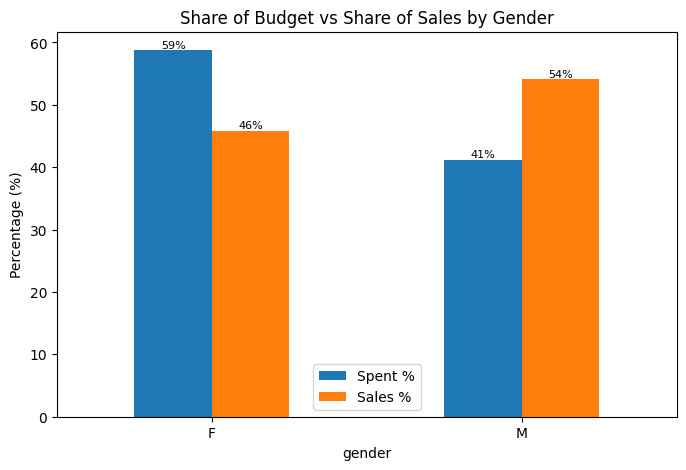

In [25]:
def share_chart(col, title):
    t = df.groupby(col)[['Spent', 'Approved_Conversion']].sum()
    t['Spent %'] = t['Spent'] / t['Spent'].sum() * 100
    t['Sales %'] = t['Approved_Conversion'] / t['Approved_Conversion'].sum() * 100
    ax = t[['Spent %', 'Sales %']].plot(kind='bar', figsize=(8, 5))
    plt.title(title)
    plt.xlabel(col)
    plt.ylabel('Percentage (%)')
    plt.xticks(rotation=0)
    for c in ax.containers:
        ax.bar_label(c, fmt='%.0f%%', fontsize=8)
    plt.show()

share_chart('age', 'Share of Budget vs Share of Sales by Age')
share_chart('gender', 'Share of Budget vs Share of Sales by Gender')

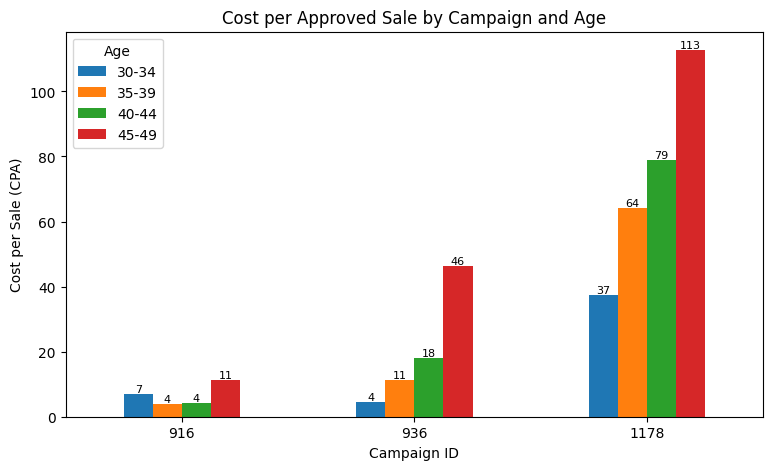

In [23]:
cpa = cross['CPA'].unstack()
ax = cpa.plot(kind='bar', figsize=(9, 5))
plt.title('Cost per Approved Sale by Campaign and Age')
plt.xlabel('Campaign ID')
plt.ylabel('Cost per Sale (CPA)')
plt.xticks(rotation=0)
plt.legend(title='Age')
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', fontsize=8)
plt.show()